# 02 CV Design

Этот ноутбук показывает, **как данные разбиваются на train/validation** при кросс-валидации:

1. **K-Fold** — делим данные на K частей (fold-ы)
2. **Multiple Reps** — повторяем с разным shuffle (разные случайные разбиения)
3. **Population grouping** — учитываем популяцию при разбиении

**Для кого**: для тех, кто хочет понять, какая часть данных идёт на обучение, а какая — на проверку качества моделей.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path

from gp_py.io import fn_load_genotype, fn_load_phenotype, fn_merge_genotype_and_phenotype
from gp_py.cv import fn_cross_validation_preparation
from gp_py.schema import MergedData

## 1. Подготовка данных (merge genotype + phenotype)

In [2]:
DATA_DIR = Path("../inst/exec_Rscript/input")

G = fn_load_genotype(str(DATA_DIR / "test_geno.Rds"))
list_pheno = fn_load_phenotype(str(DATA_DIR / "test_pheno.tsv"))

# Используем только известные фенотипы для CV
df = list_pheno['df'].copy()
y_col = list_pheno['y_col']
df_known = df[df[y_col].notna()].copy()

print(f"Общее число записей: {len(df)}")
print(f"С известным фенотипом (для CV): {len(df_known)}")

Общее число записей: 500
С известным фенотипом (для CV): 475


## 2. Подготовка CV-разбиений (K-Fold × Reps)

In [3]:
# Создаём MergedData вручную для демонстрации
# (в реальном пайплайне это делает fn_merge_genotype_and_phenotype)
ph = df_known[[list_pheno['id_col'], list_pheno['pop_col'], y_col]].copy()
ph[list_pheno['id_col']] = ph[list_pheno['id_col']].astype(str)

G_idx = G.copy()
G_idx.index = G_idx.index.astype(str)

merged = ph.merge(G_idx, left_on=list_pheno['id_col'], right_index=True, how="inner")

merged_data = MergedData(
    G=merged.drop(columns=[list_pheno['id_col'], list_pheno['pop_col'], y_col]),
    y=merged[y_col],
    pop=merged[list_pheno['pop_col']],
    trait_name=y_col,
)

print(f"Размер данных для CV: {merged_data.G.shape}")

Размер данных для CV: (475, 1000)


## 3. Генерация CV-разбиений

In [4]:
# Параметры CV
N_FOLDS = 3
N_REPS = 2

runs = fn_cross_validation_preparation(
    merged_data,
    cv_type=1,  # внутри-популяционная CV
    n_folds=N_FOLDS,
    n_reps=N_REPS,
    vec_models_to_test=("ridge", "lasso"),  # только для примера
    max_mem_gb=15.0,
    verbose=False
)

print(f"Всего CV итераций (runs): {len(runs)}")
print(f"  = {N_FOLDS} folds × {N_REPS} reps × {len(('ridge', 'lasso'))} models = {N_FOLDS * N_REPS * 2}")

Всего CV итераций (runs): 12
  = 3 folds × 2 reps × 2 models = 12


## 4. Пример разбиения для одного fold

In [5]:
# Посмотрим на конкретный run (например, rep=1, fold=1, model=ridge)
example_run = runs[0]
print(f"=== Пример: Rep {example_run.rep}, Fold {example_run.fold}, Model {example_run.model} ===")
print(f"  Train size: {len(example_run.train_idx)}")
print(f"  Valid size: {len(example_run.valid_idx)}")

# Какие ID попали в train и valid?
train_ids = merged_data.G.index[example_run.train_idx].tolist()[:5]
valid_ids = merged_data.G.index[example_run.valid_idx].tolist()[:5]
print(f"  Пример train IDs: {train_ids} ...")
print(f"  Пример valid IDs: {valid_ids} ...")

=== Пример: Rep 1, Fold 1, Model ridge ===
  Train size: 316
  Valid size: 159
  Пример train IDs: [0, 1, 2, 4, 5] ...
  Пример valid IDs: [3, 16, 17, 18, 20] ...


## 5. Визуализация fold-ов

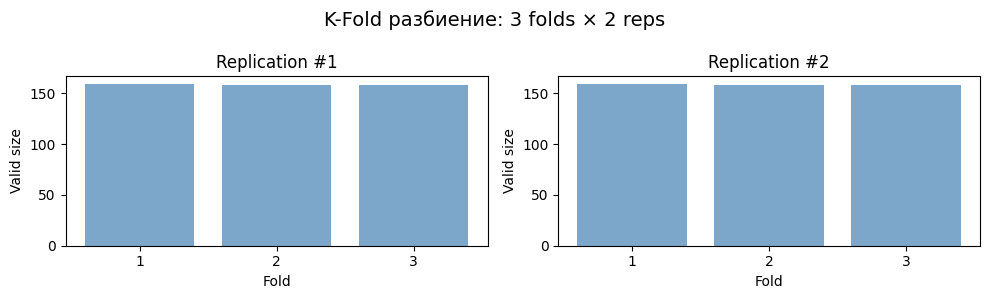

In [6]:
import matplotlib.pyplot as plt

# Для каждого rep покажем, как распределены fold-ы
fig, axes = plt.subplots(1, N_REPS, figsize=(10, 3))

for rep in range(1, N_REPS + 1):
    ax = axes[rep - 1] if N_REPS > 1 else axes
    fold_sizes = []
    for fold in range(1, N_FOLDS + 1):
        # Находим run для этого fold в данном rep
        run = next((r for r in runs if r.rep == rep and r.fold == fold and r.model == "ridge"), None)
        if run:
            fold_sizes.append(len(run.valid_idx))
    
    ax.bar(range(1, N_FOLDS + 1), fold_sizes, color='steelblue', alpha=0.7)
    ax.set_xlabel('Fold')
    ax.set_ylabel('Valid size')
    ax.set_title(f'Replication #{rep}')
    ax.set_xticks(range(1, N_FOLDS + 1))

plt.suptitle(f'K-Fold разбиение: {N_FOLDS} folds × {N_REPS} reps', fontsize=14)
plt.tight_layout()
plt.show()

## Итог

- Мы создали **K-Fold × Reps** разбиения для кросс-валидации
- Каждый fold содержит train (обучение) и validation (проверка) части
- В этом примере: 3 folds × 2 reps × 2 models = 12 итераций
- В реальном анализе таких итераций будет больше (больше моделей, больше fold-ов)

**Следующий шаг**: перейти к ноутбуку `03_models_baseline`, чтобы увидеть, как на каждом fold обучаются модели и считаются метрики.